**Nama:** Nabilah Anindya Paramesti  
**NRP:** 5027241006

# 🛰️ Satellite Image Classification

Notebook ini untuk mengklasifikasikan citra satelit ke dalam 10 kategori lahan.

---

## Struktur Notebook

| Bagian | Konten |
|--------|--------|
| **A · Setup** | Library, seed, path dataset |
| **B · EDA** | Distribusi kelas, visualisasi gambar, statistik piksel, warna per kelas |
| **C · Preprocessing** | Normalisasi, augmentasi, class weight |
| **D · Model 1** | CNN 4-Blok standar (`Conv2D`) |
| **E · Model 2** | CNN 5-Blok efisien (`SeparableConv2D`) |
| **F · Perbandingan & Error Analysis** | Metrik, confusion matrix, prediksi salah |
| **G · Inferensi** | Prediksi test, buat CSV |

---
# 🅐 Setup

Menyiapkan library, seed reproducibility, dan path dataset.

## A.1 · Import Library & Seed

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, precision_score, recall_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Deterministic ops — meminimalkan variasi hasil antar run di GPU
os.environ["TF_DETERMINISTIC_OPS"]  = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 🔑 A.1.2 · Download Dataset dari Kaggle

Silakan jalankan cell di bawah ini untuk mengunggah file `kaggle.json` Anda (didapat dari profil Kaggle > Settings > Create New API Token).

In [ ]:
from google.colab import files

# Upload file kaggle.json
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Ganti dengan nama kompetisi yang sesuai
COMPETITION_NAME = 'praktikum-modul-3-ai-2026'

# Download dan unzip
!kaggle competitions download -c {COMPETITION_NAME}
!unzip -q {COMPETITION_NAME}.zip -d dataset

print("\n✅ Dataset berhasil diunduh dan diekstrak ke folder 'dataset'")

## A.2 · Path Dataset

In [9]:
# ===== PATH DATASET =====
# Di Colab, dataset telah di-unzip ke folder 'dataset'
BASE_DIR = Path("dataset")

# Cari folder yang berisi 'train' dan 'test'
def find_dataset_root(base):
    if not base.exists():
        return None
    for root, dirs, files in os.walk(base):
        if 'train' in dirs and 'test' in dirs:
            return Path(root)
    return None

DATASET_ROOT = find_dataset_root(BASE_DIR)

if DATASET_ROOT is None:
    # Fallback jika struktur folder berbeda
    DATASET_ROOT = Path("dataset")

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR  = DATASET_ROOT / "test"

# Cari sample_submission.csv secara aman.
submission_candidates = list(DATASET_ROOT.glob("sample_submission*.csv"))
if len(submission_candidates) > 0:
    SUBMISSION_SAMPLE = submission_candidates[0]
else:
    SUBMISSION_SAMPLE = DATASET_ROOT / "sample_submission.csv"

print(f"Dataset root       : {DATASET_ROOT}")
print(f"Train dir          : {TRAIN_DIR}  | Exist: {TRAIN_DIR.exists()}")
print(f"Test dir           : {TEST_DIR}   | Exist: {TEST_DIR.exists()}")
print(f"Sample submission  : {SUBMISSION_SAMPLE} | Exist: {SUBMISSION_SAMPLE.exists()}")

# Tampilkan daftar kelas dari subfolder train
if TRAIN_DIR.exists():
    CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
    NUM_CLASSES = len(CLASSES)
    print(f"\nJumlah kelas : {NUM_CLASSES}")
    print(f"Daftar kelas : {CLASSES}")
else:
    print("\n⚠️ Folder TRAIN_DIR tidak ditemukan. Pastikan path sudah benar.")

Dataset root       : dataset
Train dir          : dataset/train  | Exist: True
Test dir           : dataset/test   | Exist: True
Sample submission  : dataset/sample_submission.csv | Exist: True

Jumlah kelas : 10
Daftar kelas : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


---
# 🅑 Exploratory Data Analysis (EDA)

Memahami karakteristik dataset sebelum membangun model.

## B.1 · Visualisasi Sampel Gambar per Kelas

Melihat satu contoh gambar dari setiap kelas untuk memahami tampilan visual data.

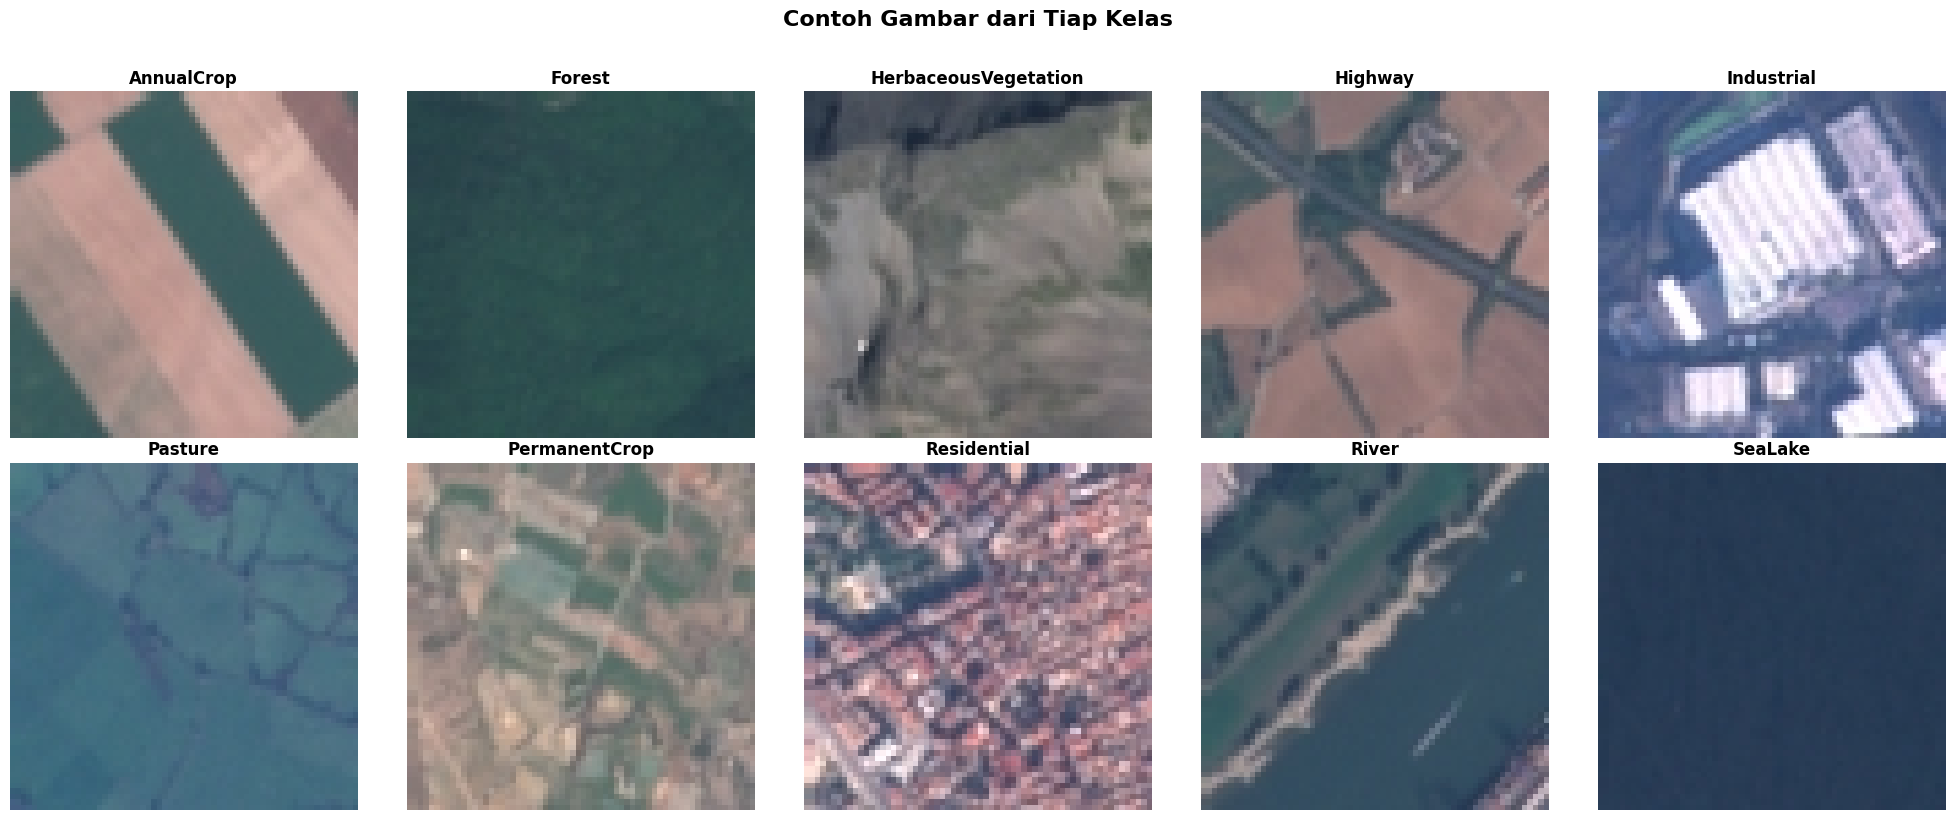

✅ Contoh gambar berhasil ditampilkan.


In [10]:
# ===== TAMPILKAN SATU GAMBAR PER KELAS =====
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, cls in enumerate(CLASSES):
    class_folder = TRAIN_DIR / cls
    img_files = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.png"))
    if img_files:
        sample_img_path = random.choice(img_files)
        img = mpimg.imread(sample_img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(cls, fontsize=12, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle("Contoh Gambar dari Tiap Kelas", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✅ Contoh gambar berhasil ditampilkan.")

## B.2 · Distribusi Jumlah Gambar per Kelas

Memeriksa apakah dataset seimbang (*balanced*) atau tidak. Dataset yang tidak seimbang dapat membuat model bias terhadap kelas mayoritas.

               Kelas  Jumlah Gambar
          AnnualCrop            766
             SeaLake            731
             Pasture            702
              Forest            654
               River            621
          Industrial            559
         Residential            479
HerbaceousVegetation            439
             Highway            340
       PermanentCrop            322

Total gambar training : 5613
Total gambar test     : 1200


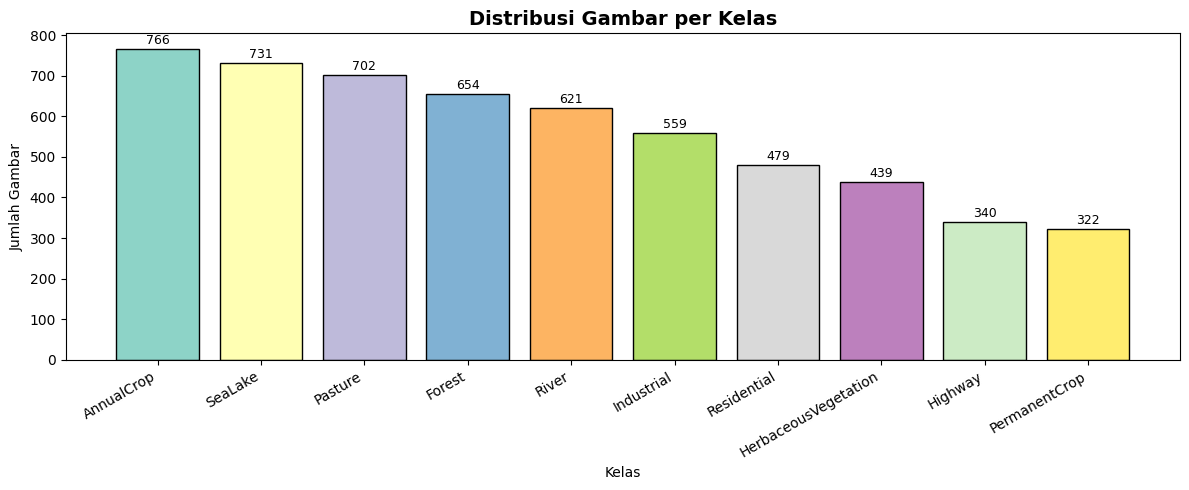


Rasio kelas terbanyak vs tersedikit: 2.38x
⚠️ Dataset tidak seimbang — perhatikan metrik evaluasi!


In [11]:
# ===== HITUNG JUMLAH GAMBAR PER KELAS =====
class_counts = {}
for cls in CLASSES:
    class_folder = TRAIN_DIR / cls
    imgs = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.png"))
    class_counts[cls] = len(imgs)

# Tampilkan sebagai tabel
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Kelas', 'Jumlah Gambar'])
df_counts = df_counts.sort_values('Jumlah Gambar', ascending=False).reset_index(drop=True)
print(df_counts.to_string(index=False))
print(f"\nTotal gambar training : {df_counts['Jumlah Gambar'].sum()}")
print(f"Total gambar test     : {len(list(TEST_DIR.glob('*.jpg')) + list(TEST_DIR.glob('*.png')))}")

# Visualisasi bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = ax.bar(df_counts['Kelas'], df_counts['Jumlah Gambar'], color=colors, edgecolor='black')
ax.set_title('Distribusi Gambar per Kelas', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah Gambar')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, df_counts['Jumlah Gambar']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Cek balance
max_c = df_counts['Jumlah Gambar'].max()
min_c = df_counts['Jumlah Gambar'].min()
ratio = max_c / min_c
print(f"\nRasio kelas terbanyak vs tersedikit: {ratio:.2f}x")
if ratio < 2:
    print("✅ Dataset relatif seimbang.")
else:
    print("⚠️ Dataset tidak seimbang — perhatikan metrik evaluasi!")

## B.3 · Statistik Dimensi & Kecerahan Piksel

Mengecek ukuran asli gambar dan distribusi kecerahan untuk memahami karakteristik visual dataset.

===== Statistik Dimensi Gambar =====
Lebar  — min:64  max:64  rata-rata:64.0 px
Tinggi — min:64  max:64  rata-rata:64.0 px
Ukuran unik: {(64, 64)}

===== Statistik Kecerahan Piksel =====
Min:0.169  Max:0.762  Mean:0.364  Std:0.107


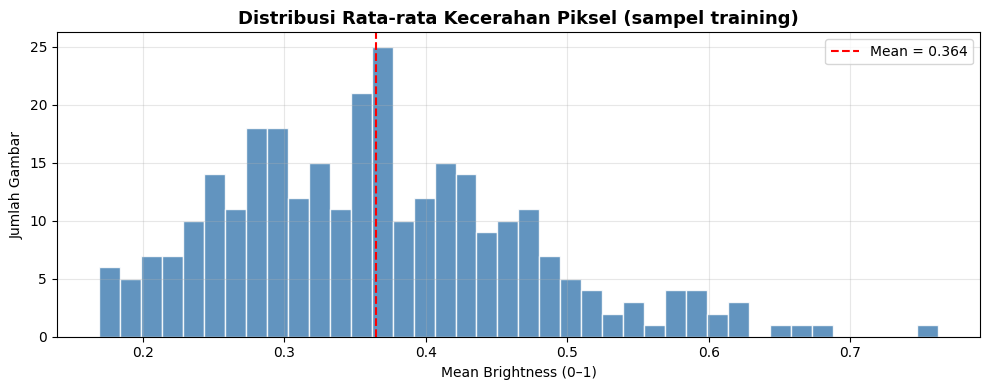

In [12]:
# Sampel 30 gambar per kelas untuk efisiensi
pixel_means, img_widths, img_heights = [], [], []
SAMPLES_PER_CLASS = 30

for cls in CLASSES:
    folder = TRAIN_DIR / cls
    imgs = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))[:SAMPLES_PER_CLASS]
    for p in imgs:
        try:
            with Image.open(p) as im:
                img_widths.append(im.width)
                img_heights.append(im.height)
                arr = np.array(im.convert("RGB"), dtype=np.float32) / 255.0
                pixel_means.append(arr.mean())
        except Exception:
            pass

print("===== Statistik Dimensi Gambar =====")
unique_sizes = set(zip(img_widths, img_heights))
print(f"Lebar  — min:{min(img_widths)}  max:{max(img_widths)}  rata-rata:{np.mean(img_widths):.1f} px")
print(f"Tinggi — min:{min(img_heights)}  max:{max(img_heights)}  rata-rata:{np.mean(img_heights):.1f} px")
print(f"Ukuran unik: {unique_sizes if len(unique_sizes)<=5 else str(len(unique_sizes))+' variasi'}")

print(f"\n===== Statistik Kecerahan Piksel =====")
print(f"Min:{min(pixel_means):.3f}  Max:{max(pixel_means):.3f}  Mean:{np.mean(pixel_means):.3f}  Std:{np.std(pixel_means):.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pixel_means, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(pixel_means), color='red', linestyle='--',
           label=f'Mean = {np.mean(pixel_means):.3f}')
ax.set_title("Distribusi Rata-rata Kecerahan Piksel (sampel training)", fontsize=13, fontweight='bold')
ax.set_xlabel("Mean Brightness (0–1)")
ax.set_ylabel("Jumlah Gambar")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## B.4 · Rata-rata Warna RGB per Kelas

Setiap kelas lahan cenderung memiliki dominasi warna berbeda (misal: SeaLake → biru). Analisis ini membantu memahami seberapa mudah kelas-kelas tersebut dibedakan secara visual.

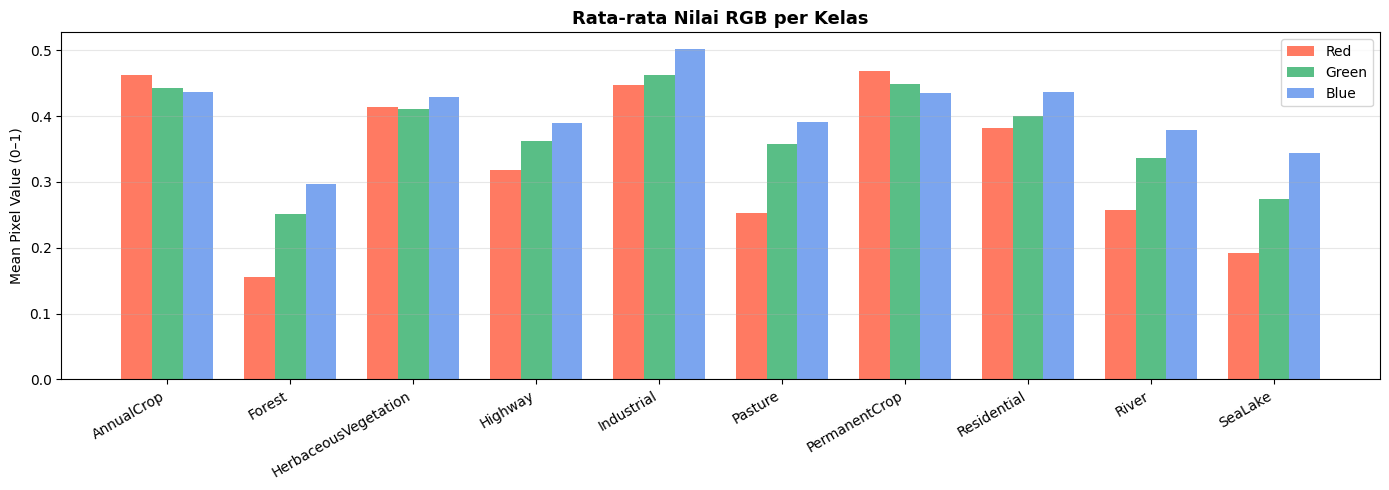


Dominansi warna per kelas:
  AnnualCrop               : R=0.462  G=0.443  B=0.437  → dominan: Red
  Forest                   : R=0.155  G=0.252  B=0.297  → dominan: Blue
  HerbaceousVegetation     : R=0.414  G=0.411  B=0.429  → dominan: Blue
  Highway                  : R=0.318  G=0.362  B=0.390  → dominan: Blue
  Industrial               : R=0.448  G=0.462  B=0.502  → dominan: Blue
  Pasture                  : R=0.252  G=0.357  B=0.390  → dominan: Blue
  PermanentCrop            : R=0.469  G=0.448  B=0.434  → dominan: Red
  Residential              : R=0.382  G=0.399  B=0.437  → dominan: Blue
  River                    : R=0.257  G=0.336  B=0.378  → dominan: Blue
  SeaLake                  : R=0.191  G=0.275  B=0.344  → dominan: Blue


In [13]:
class_rgb_means = {}
SAMPLES_RGB = 50

for cls in CLASSES:
    folder = TRAIN_DIR / cls
    imgs = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))[:SAMPLES_RGB]
    r_list, g_list, b_list = [], [], []
    for p in imgs:
        try:
            arr = np.array(Image.open(p).convert("RGB"), dtype=np.float32) / 255.0
            r_list.append(arr[:,:,0].mean())
            g_list.append(arr[:,:,1].mean())
            b_list.append(arr[:,:,2].mean())
        except Exception:
            pass
    class_rgb_means[cls] = (np.mean(r_list), np.mean(g_list), np.mean(b_list))

x = np.arange(len(CLASSES)); w = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, [class_rgb_means[c][0] for c in CLASSES], w, label='Red',   color='tomato',          alpha=0.85)
ax.bar(x,     [class_rgb_means[c][1] for c in CLASSES], w, label='Green', color='mediumseagreen',   alpha=0.85)
ax.bar(x + w, [class_rgb_means[c][2] for c in CLASSES], w, label='Blue',  color='cornflowerblue',   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_title("Rata-rata Nilai RGB per Kelas", fontsize=13, fontweight='bold')
ax.set_ylabel("Mean Pixel Value (0–1)")
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print("\nDominansi warna per kelas:")
for cls in CLASSES:
    r, g, b = class_rgb_means[cls]
    dominant = ['Red','Green','Blue'][np.argmax([r,g,b])]
    print(f"  {cls:<25}: R={r:.3f}  G={g:.3f}  B={b:.3f}  → dominan: {dominant}")

---
# 🅒 Preprocessing & Augmentasi

Normalisasi dan augmentasi data sebagai persiapan training.

## C.1 · Hyperparameter

Konfigurasi awal yang digunakan untuk **kedua model** agar perbandingan adil (resolusi, batch size, dll. sama).

In [14]:
# ===== HYPERPARAMETER =====

IMG_SIZE      = (128, 128)  # ⬆️ Naik dari 64→128: model melihat detail 4× lebih banyak
BATCH_SIZE    = 32           # Tetap 32, aman untuk T4 GPU
EPOCHS        = 60           # ⬆️ Lebih banyak, EarlyStopping yang mengontrol
LEARNING_RATE = 1e-3         # Adam default
DROPOUT_RATE  = 0.4          # Dropout di classifier
VAL_SPLIT     = 0.15         # 15% untuk validasi
LABEL_SMOOTHING = 0.05       # 🆕 Mencegah model terlalu overconfident

print("===== Konfigurasi Hyperparameter =====")
print(f"Image size      : {IMG_SIZE}  ← naik dari 64×64!")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Max epochs      : {EPOCHS}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Dropout rate    : {DROPOUT_RATE}")
print(f"Label smoothing : {LABEL_SMOOTHING}")
print(f"Val split       : {VAL_SPLIT*100:.0f}%")


===== Konfigurasi Hyperparameter =====
Image size      : (128, 128)  ← naik dari 64×64!
Batch size      : 32
Max epochs      : 60
Learning rate   : 0.001
Dropout rate    : 0.4
Label smoothing : 0.05
Val split       : 15%


*   **`IMG_SIZE (128, 128)`**: Resolusi gambar yang masuk ke model. Semakin besar, semakin banyak detail yang ditangkap, tapi beban komputasi bertambah.
*   **`BATCH_SIZE (32)`**: Jumlah gambar yang diproses model dalam satu kali update bobot. Angka 32 adalah titik tengah yang stabil untuk memori GPU.
*   **`EPOCHS (60)`**: Berapa kali model 'melihat' seluruh dataset selama latihan.
*   **`LEARNING_RATE (1e-3)`**: Ukuran langkah model saat memperbaiki kesalahan. Terlalu besar bisa bikin gagal konvergen, terlalu kecil bikin proses sangat lambat.
*   **`DROPOUT_RATE (0.4)`**: Persentase neuron yang 'dimatikan' secara acak saat training untuk mencegah model menghafal data (overfitting).
*   **`VAL_SPLIT (0.15)`**: Porsi data (15%) yang disisihkan hanya untuk menguji akurasi model pada data baru selama proses latihan.
*   **`LABEL_SMOOTHING (0.05)`**: Teknik agar model tidak terlalu percaya diri (overconfident) pada satu label, sehingga lebih fleksibel dan general.

## C.2 · Data Generator & Augmentasi

**Augmentasi** hanya diterapkan pada training set dan tidak pada validation agar evaluasi realistis.

Augmentasi yang dipilih untuk citra satelit:
- `horizontal_flip` & `vertical_flip` — objek satelit tidak punya orientasi tetap  
- `rotation_range=45` — variasi sudut pengambilan  
- `zoom_range=0.1` — simulasi variasi ketinggian  
- `brightness_range` — simulasi variasi pencahayaan

In [15]:
# ===== DATA GENERATOR DENGAN AUGMENTASI =====

train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    validation_split   = VAL_SPLIT,
    horizontal_flip    = True,
    vertical_flip      = True,
    rotation_range     = 90,
    zoom_range         = 0.15,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    brightness_range   = [0.80, 1.20],
    channel_shift_range= 15.0,
    fill_mode          = 'reflect'
)

val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = VAL_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    directory   = TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    seed        = SEED,
    shuffle     = True
)

val_generator = val_datagen.flow_from_directory(
    directory   = TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    seed        = SEED,
    shuffle     = False
)

CLASS_INDICES = train_generator.class_indices
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}
CLASS_NAMES   = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

print("\nClass index mapping:")
for cls, idx in CLASS_INDICES.items():
    print(f"  {idx}: {cls}")

assert train_generator.class_indices == val_generator.class_indices
print("\n✅ Train generator: augmentasi aktif.")
print("✅ Validation generator: hanya rescale.")


Found 4776 images belonging to 10 classes.
Found 837 images belonging to 10 classes.

Class index mapping:
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake

✅ Train generator: augmentasi aktif.
✅ Validation generator: hanya rescale.


*   **`Found 4776 images belonging to 10 classes`**: Menunjukkan jumlah total gambar yang ditemukan di folder `train`. Sistem mendeteksi ada 10 kategori (kelas) berbeda.
*   **`Found 837 images belonging to 10 classes`**: Ini adalah jumlah gambar yang disisihkan otomatis untuk **Validasi** (berdasarkan `VAL_SPLIT=0.15` atau 15% dari total data).
*   **`Class index mapping`**: Daftar angka (0-9) yang digunakan komputer untuk mengenali nama kelas.
    *   Contoh: Angka `0` mewakili `AnnualCrop`, angka `9` mewakili `SeaLake`.
*   **`Train generator: augmentasi aktif`**: Artinya data training akan dimodifikasi (diputar, dizoom, dll.) secara otomatis setiap epoch agar model lebih pintar dan tidak cepat hafal data.

## C.3 · Visualisasi Hasil Augmentasi

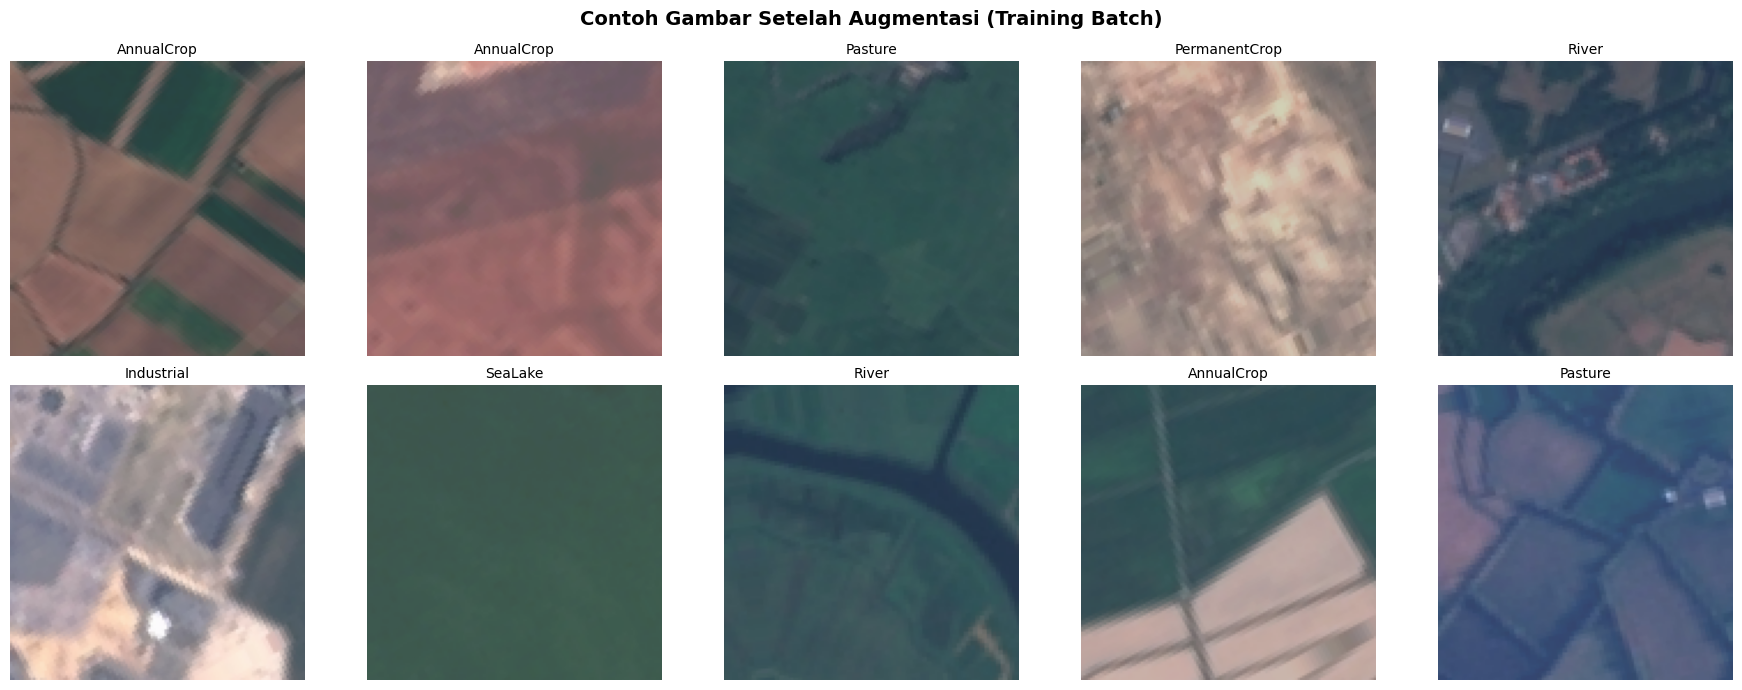

✅ Generator di-reset, siap untuk training.


In [16]:
# Reset generator setelah dipakai visualisasi agar posisi kembali ke awal sebelum training
sample_batch_x, sample_batch_y = next(iter(train_generator))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(sample_batch_x[i])
    label_idx = np.argmax(sample_batch_y[i])
    axes[i].set_title(IDX_TO_CLASS[label_idx], fontsize=10)
    axes[i].axis('off')
plt.suptitle("Contoh Gambar Setelah Augmentasi (Training Batch)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ⚠️ Wajib reset setelah next(iter(...)) agar training mulai dari awal
train_generator.reset()
val_generator.reset()
print("✅ Generator di-reset, siap untuk training.")

## C.4 · Class Weight

Menghitung bobot per kelas untuk mengatasi ketidakseimbangan dataset. Kelas yang lebih sedikit diberi bobot lebih tinggi saat training agar model tidak 'meremehkan' atau mengabaikan kelas tersebut saat proses belajar.

In [17]:
classes_arr = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_arr,
    y=train_generator.classes
)
CLASS_WEIGHTS = dict(zip(classes_arr, weights))

print("Class weights:")
for idx in sorted(CLASS_WEIGHTS):
    print(f"  {idx:2d} — {IDX_TO_CLASS[idx]:<25}: {CLASS_WEIGHTS[idx]:.4f}")

Class weights:
   0 — AnnualCrop               : 0.7325
   1 — Forest                   : 0.8590
   2 — HerbaceousVegetation     : 1.2770
   3 — Highway                  : 1.6526
   4 — Industrial               : 1.0034
   5 — Pasture                  : 0.8000
   6 — PermanentCrop            : 1.7431
   7 — Residential              : 1.1706
   8 — River                    : 0.9045
   9 — SeaLake                  : 0.7678


## C.5 · Fungsi Helper Visualisasi Training

Didefinisikan di sini agar bisa dipakai ulang untuk Model 1 dan Model 2.

In [18]:
def plot_training_history(history, model_name="Model"):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    ep       = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    axes[0].plot(ep, acc,     'b-o', label='Train',      markersize=3)
    axes[0].plot(ep, val_acc, 'r-o', label='Validation', markersize=3)
    best_ep = int(np.argmax(val_acc))
    axes[0].scatter([best_ep+1], [val_acc[best_ep]], s=80, color='red', zorder=5,
                    label=f'Best val: {val_acc[best_ep]:.4f}')
    axes[0].set_title(f'Accuracy — {model_name}', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim([0, 1.05]); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(ep, loss,     'b-o', label='Train',      markersize=3)
    axes[1].plot(ep, val_loss, 'r-o', label='Validation', markersize=3)
    axes[1].set_title(f'Loss — {model_name}', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    # Diagnosa
    gap = acc[-1] - val_acc[-1]
    print(f"\n📊 Diagnosa {model_name}:")
    print(f"   Train acc  : {acc[-1]:.4f}  |  Val acc  : {val_acc[-1]:.4f}  |  Gap : {gap:.4f}")
    if acc[-1] < 0.60 and val_acc[-1] < 0.60:
        print("   ❌ UNDERFITTING — tambah layer/filter atau kurangi dropout")
    elif gap > 0.15:
        print("   ⚠️  OVERFITTING — naikkan dropout atau perkuat augmentasi")
    else:
        print("   ✅ GOOD FIT")

print("✅ Fungsi plot_training_history siap.")

✅ Fungsi plot_training_history siap.


*   **Grafik Akurasi & Loss**: Memetakan performa model pada data training vs validation di setiap epoch untuk melihat seberapa cepat model belajar.
*   **Diagnosa Otomatis**: Menghitung selisih (gap) antara akurasi training dan validasi untuk mendeteksi apakah model sudah pas (*Good Fit*), terlalu menghafal (*Overfitting*), atau kurang belajar (*Underfitting*).

---
# 🅓 Model 1 — CNN 4-Blok (Conv2D)

**Arsitektur:** 4 blok konvolusi dengan `Conv2D` double per blok, diikuti `GlobalAveragePooling2D` dan classifier.

| Blok | Filter | Output Ukuran (dari 64×64) |
|------|--------|---------------------------|
| Blok 1 | 32 | 32×32 |
| Blok 2 | 64 | 16×16 |
| Blok 3 | 128 | 8×8 |
| Blok 4 | 256 | 4×4 |
| GAP + Dense | — | 10 (softmax) |

## D.1 · Arsitektur Model 1

In [19]:
# ===== BANGUN CNN CUSTOM =====

def build_custom_cnn(input_shape, num_classes, dropout_rate=0.4):
    """
    CNN custom dari nol — tanpa transfer learning, tanpa pretrained model.

    Pola setiap blok konvolusi:
    Conv2D → BatchNorm → Activation → Conv2D → BatchNorm → Activation → MaxPool

    Double Conv di setiap blok membantu model belajar fitur lebih kompleks
    tanpa harus memperdalam jaringan terlalu banyak.
    """
    model = models.Sequential(name='Custom_CNN_Satellite')

    # ── INPUT LAYER ─────────────────────────────────────────────────────────
    model.add(layers.Input(shape=input_shape))

    # ── BLOK 1: Filter kecil, tangkap fitur dasar (tepi, warna) ─────────────
    model.add(layers.Conv2D(32, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))          # 64×64 → 32×32
    model.add(layers.Dropout(0.1))                # Dropout ringan di awal

    # ── BLOK 2: Lebih banyak filter, fitur lebih kompleks ───────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))          # 32×32 → 16×16
    model.add(layers.Dropout(0.2))

    # ── BLOK 3: Tangkap pola abstrak (bentuk ladang, jalan, dll.) ───────────
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))          # 16×16 → 8×8
    model.add(layers.Dropout(0.3))

    # ── BLOK 4: Fitur tingkat tinggi ─────────────────────────────────────────
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))          # 8×8 → 4×4
    model.add(layers.Dropout(0.3))

    # ── POOLING GLOBAL ──────────────────────────────────────────────────────
    # GlobalAveragePooling lebih baik dari Flatten untuk mengurangi overfitting
    # karena merata-ratakan setiap feature map menjadi 1 angka
    model.add(layers.GlobalAveragePooling2D())

    # ── CLASSIFIER (Fully Connected Layers) ─────────────────────────────────
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(128))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(dropout_rate))

    # ── OUTPUT LAYER ─────────────────────────────────────────────────────────
    # Softmax: mengubah output menjadi probabilitas yang jumlahnya = 1
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


# Buat model
input_shape = IMG_SIZE + (3,)   # (64, 64, 3) — 3 channel RGB
model = build_custom_cnn(input_shape, NUM_CLASSES, DROPOUT_RATE)

# Tampilkan ringkasan arsitektur
model.summary()

Model: "Custom_CNN_Satellite"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,277,610 (4.87 MB)

 Trainable params: 1,274,922 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

## D.2 · Compile & Callback Model 1

*   **Compile**: Menyiapkan 'otak' model dengan **Adam Optimizer** (pengatur langkah belajar) dan **Loss Function** (pengukur kesalahan). Di sini kita juga menggunakan *Label Smoothing* agar model tidak terlalu kaku/overconfident.
*   **Callbacks**: Fitur otomatis selama training:
    *   **EarlyStopping**: Menghentikan latihan otomatis jika akurasi sudah tidak naik lagi (hemat waktu).
    *   **ReduceLROnPlateau**: Mengurangi kecepatan belajar jika model mulai 'mentok' agar bisa lebih teliti.
    *   **ModelCheckpoint**: Otomatis menyimpan file model yang paling bagus hasilnya.

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
BEST_MODEL1_PATH = 'best_model1_conv2d.keras'

optimizer1 = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Label smoothing: target bergeser dari 1.0→0.95, 0.0→0.006
# Model tidak bisa terlalu "overconfident" → lebih general
loss_fn1 = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

model.compile(
    optimizer = optimizer1,
    loss      = loss_fn1,
    metrics   = ['accuracy']
)

callbacks1 = [
    EarlyStopping(
        monitor='val_accuracy', mode='max', patience=12,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=5, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        filepath=BEST_MODEL1_PATH,
        monitor='val_accuracy', mode='max',
        save_best_only=True, verbose=1
    ),
]

print(f"✅ Model 1 siap — total params: {model.count_params():,}")
print(f"   Optimizer       : Adam (lr={LEARNING_RATE})")
print(f"   Loss            : CategoricalCrossentropy (label_smoothing={LABEL_SMOOTHING})")
print(f"   Checkpoint      : {BEST_MODEL1_PATH}")


✅ Model 1 siap — total params: 1,277,610
   Optimizer       : Adam (lr=0.001)
   Loss            : CategoricalCrossentropy (label_smoothing=0.05)
   Checkpoint      : best_model1_conv2d.keras


## D.3 · Training Model 1

In [22]:
# Reset seed & generator agar training Model 1 deterministic dan mulai dari awal
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
train_generator.reset(); val_generator.reset()

print("🚀 Training Model 1 — CNN 4-Blok (Conv2D)")
print(f"   Training samples   : {train_generator.samples}")
print(f"   Validation samples : {val_generator.samples}")
print(f"   Max epochs         : {EPOCHS}")
print("-" * 50)

history1 = model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = callbacks1,
    verbose         = 1
)

best_val1 = max(history1.history['val_accuracy'])
best_ep1  = int(np.argmax(history1.history['val_accuracy'])) + 1
print(f"\n✅ Training Model 1 selesai!")
print(f"   Best val_accuracy : {best_val1:.4f} ({best_val1*100:.2f}%) pada epoch {best_ep1}")

🚀 Training Model 1 — CNN 4-Blok (Conv2D)
   Training samples   : 4776
   Validation samples : 837
   Max epochs         : 60
--------------------------------------------------
Epoch 1/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.2957 - loss: 2.1409
Epoch 1: val_accuracy improved from None to 0.08483, saving model to best_model1_conv2d.keras

Epoch 1: finished saving model to best_model1_conv2d.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 58s 300ms/step - accuracy: 0.3855 - loss: 1.8698 - val_accuracy: 0.0848 - val_loss: 3.0675 - learning_rate: 0.0010
Epoch 2/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5029 - loss: 1.5929
Epoch 2: val_accuracy improved from 0.08483 to 0.19355, saving model to best_model1_conv2d.keras

Epoch 2: finished saving model to best_model1_conv2d.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 294ms/step - accuracy: 0.5178 - loss: 1.5683 - val_accuracy: 0.1935 - val_loss: 2.9265 - learning_rate: 0.0010
Epoch 3/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/

## D.4 · Kurva Training Model 1

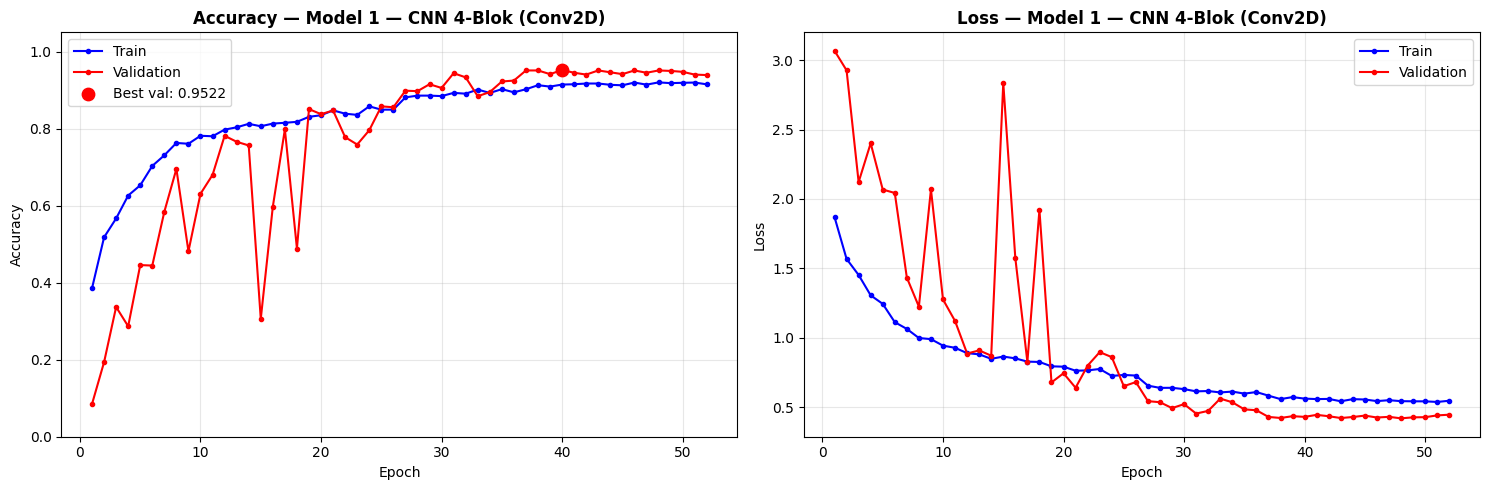


📊 Diagnosa Model 1 — CNN 4-Blok (Conv2D):
   Train acc  : 0.9150  |  Val acc  : 0.9391  |  Gap : -0.0241
   ✅ GOOD FIT


In [23]:
plot_training_history(history1, 'Model 1 — CNN 4-Blok (Conv2D)')

## D.5 · Evaluasi Model 1 pada Validation Set

In [24]:
print(f"📂 Memuat model terbaik dari: {BEST_MODEL1_PATH}")
best_model1 = keras.models.load_model(BEST_MODEL1_PATH)

val_generator.reset()
val_loss1, val_acc1 = best_model1.evaluate(val_generator, verbose=1)
print(f"\nModel 1 — Val Loss     : {val_loss1:.4f}")
print(f"Model 1 — Val Accuracy : {val_acc1:.4f} ({val_acc1*100:.2f}%)")

📂 Memuat model terbaik dari: best_model1_conv2d.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9522 - loss: 0.4308

Model 1 — Val Loss     : 0.4308
Model 1 — Val Accuracy : 0.9522 (95.22%)


---
# 🅔 Model 2 — MBConv-Style CNN (Mobile Inverted Bottleneck Convolution)

**Perbedaan utama vs Model 1:**

| Aspek | Model 1 | Model 2 |
|-------|---------|---------|
| Tipe konvolusi | `Conv2D` biasa | `DepthwiseConv2D` + `Conv2D` 1×1 (MBConv) |
| Struktur blok | Double Conv → Pool | Expand → Depthwise → Squeeze → Skip |
| Skip connection | ❌ | ✅ Residual add |
| Squeeze-Excitation | ❌ | ✅ Channel attention |
| Parameter | Lebih banyak | Lebih efisien |

**Cara kerja MBConv block:**
```
Input → Expand (1×1 Conv, naikkan channel)
      → DepthwiseConv2D (3×3, per channel)
      → Squeeze-Excitation (reweight channel)
      → Project (1×1 Conv, turunkan channel)
      → Add(shortcut)  ← Skip connection
```

## E.1 · Arsitektur Model 2

In [25]:
# ===== MODEL 2: MBConv-Style CNN dari Nol =====
# Terinspirasi EfficientNet tapi DIBANGUN DARI NOL — tidak ada pretrained weights.
# Menggunakan layer dasar Keras: DepthwiseConv2D, Conv2D, GlobalAveragePooling2D, Dense, dll.

def mbconv_block(x, in_channels, out_channels, expand_ratio=4, stride=1):
    """
    Mobile Inverted Bottleneck Convolution (MBConv) dari nol.

    Langkah:
    1. Expand  : Conv2D 1×1, naikkan channel → in_channels * expand_ratio
    2. Depthwise: DepthwiseConv2D 3×3, konvolusi per channel
    3. SE block : Squeeze-Excitation — reweight seberapa penting tiap channel
    4. Project  : Conv2D 1×1, turunkan channel → out_channels
    5. Skip     : tambahkan shortcut jika dimensi cocok
    """
    expanded = in_channels * expand_ratio
    shortcut = x

    # 1. Expand
    x = layers.Conv2D(expanded, (1,1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)   # Swish lebih smooth dari ReLU

    # 2. Depthwise Conv
    x = layers.DepthwiseConv2D((3,3), strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    # 3. Squeeze-Excitation (channel attention)
    se_ratio = 4
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, expanded))(se)
    se = layers.Conv2D(max(1, expanded // se_ratio), (1,1), activation='swish')(se)
    se = layers.Conv2D(expanded, (1,1), activation='sigmoid')(se)
    x  = layers.Multiply()([x, se])

    # 4. Project
    x = layers.Conv2D(out_channels, (1,1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # 5. Skip connection (hanya jika stride=1 dan channel sama)
    if stride == 1 and in_channels == out_channels:
        x = layers.Add()([x, shortcut])

    return x


def build_mbconv_cnn(input_shape, num_classes, dropout_rate=0.4):
    """
    CNN berbasis MBConv dibangun dari nol.
    Tidak ada pretrained weights — semua bobot diinisialisasi acak.
    """
    inputs = keras.Input(shape=input_shape, name='input_image')

    # Stem
    x = layers.Conv2D(32, (3,3), strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    # 128→64

    # Stage 1 — 32 channel
    x = mbconv_block(x, in_channels=32,  out_channels=24,  expand_ratio=1)
    x = mbconv_block(x, in_channels=24,  out_channels=24,  expand_ratio=1)

    # Stage 2 — stride 2 untuk downsample
    x = layers.DepthwiseConv2D((3,3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Conv2D(40, (1,1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    # 64→32
    x = mbconv_block(x, in_channels=40, out_channels=40, expand_ratio=4)
    x = mbconv_block(x, in_channels=40, out_channels=40, expand_ratio=4)
    x = layers.Dropout(0.1)(x)

    # Stage 3 — stride 2
    x = layers.DepthwiseConv2D((3,3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Conv2D(80, (1,1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    # 32→16
    x = mbconv_block(x, in_channels=80, out_channels=80, expand_ratio=4)
    x = mbconv_block(x, in_channels=80, out_channels=80, expand_ratio=4)
    x = layers.Dropout(0.15)(x)

    # Stage 4 — stride 2
    x = layers.DepthwiseConv2D((3,3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Conv2D(160, (1,1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    # 16→8
    x = mbconv_block(x, in_channels=160, out_channels=160, expand_ratio=4)
    x = mbconv_block(x, in_channels=160, out_channels=160, expand_ratio=4)
    x = layers.Dropout(0.20)(x)

    # Stage 5 — stride 2
    x = layers.DepthwiseConv2D((3,3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Conv2D(256, (1,1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    # 8→4
    x = layers.Dropout(0.25)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return keras.Model(inputs, outputs, name='MBConv_CNN_FromScratch')


model2 = build_mbconv_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
)
model2.summary()
print(f"\nModel 1 params (Conv2D)  : {model.count_params():,}")
print(f"Model 2 params (MBConv)  : {model2.count_params():,}")
print("\n✅ Model 2 dibangun.")


Model: "MBConv_CNN_FromScratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │        864 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │      1,024 │ activation_10[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 64, 64,    │        288 │ activation_11[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_12[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 1, 1, 8)   │        264 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 1, 1, 32)  │        288 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64,    │          0 │ activation_12[0]… │
│                     │ 32)               │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │        768 │ multiply[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         96 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │        576 │ batch_normalizat

 Total params: 1,257,416 (4.80 MB)

 Trainable params: 1,244,760 (4.75 MB)

 Non-trainable params: 12,656 (49.44 KB)


Model 1 params (Conv2D)  : 1,277,610
Model 2 params (MBConv)  : 1,257,416

✅ Model 2 dibangun.


## E.2 · Compile & Callback Model 2

In [26]:
BEST_MODEL2_PATH = 'best_model2_mbconv.keras'

optimizer2 = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn2   = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

model2.compile(
    optimizer = optimizer2,
    loss      = loss_fn2,
    metrics   = ['accuracy']
)

callbacks2 = [
    EarlyStopping(
        monitor='val_accuracy', mode='max', patience=12,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=5, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        filepath=BEST_MODEL2_PATH,
        monitor='val_accuracy', mode='max',
        save_best_only=True, verbose=1
    ),
]

print(f"✅ Model 2 siap — total params: {model2.count_params():,}")
print(f"   Optimizer       : Adam (lr={LEARNING_RATE})")
print(f"   Loss            : CategoricalCrossentropy (label_smoothing={LABEL_SMOOTHING})")
print(f"   Checkpoint      : {BEST_MODEL2_PATH}")


✅ Model 2 siap — total params: 1,257,416
   Optimizer       : Adam (lr=0.001)
   Loss            : CategoricalCrossentropy (label_smoothing=0.05)
   Checkpoint      : best_model2_mbconv.keras


## E.3 · Training Model 2

In [27]:
# Reset seed & generator sebelum training Model 2
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
train_generator.reset(); val_generator.reset()

print("🚀 Training Model 2 — MBConv CNN dari Nol")
print(f"   Training samples   : {train_generator.samples}")
print(f"   Validation samples : {val_generator.samples}")
print(f"   Max epochs         : {EPOCHS}")
print("-" * 50)

history2 = model2.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = callbacks2,
    verbose         = 1
)

best_val2 = max(history2.history['val_accuracy'])
best_ep2  = int(np.argmax(history2.history['val_accuracy'])) + 1
print(f"\n✅ Training Model 2 selesai!")
print(f"   Best val_accuracy : {best_val2:.4f} ({best_val2*100:.2f}%) pada epoch {best_ep2}")

🚀 Training Model 2 — MBConv CNN dari Nol
   Training samples   : 4776
   Validation samples : 837
   Max epochs         : 60
--------------------------------------------------
Epoch 1/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3551 - loss: 1.9178
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_model2_mbconv.keras

Epoch 1: finished saving model to best_model2_mbconv.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 321ms/step - accuracy: 0.4343 - loss: 1.7155 - val_accuracy: 0.1111 - val_loss: 2.5139 - learning_rate: 0.0010
Epoch 2/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5585 - loss: 1.4334
Epoch 2: val_accuracy improved from 0.11111 to 0.12545, saving model to best_model2_mbconv.keras

Epoch 2: finished saving model to best_model2_mbconv.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 299ms/step - accuracy: 0.5844 - loss: 1.3853 - val_accuracy: 0.1254 - val_loss: 2.8790 - learning_rate: 0.0010
Epoch 3/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/

## E.4 · Kurva Training Model 2

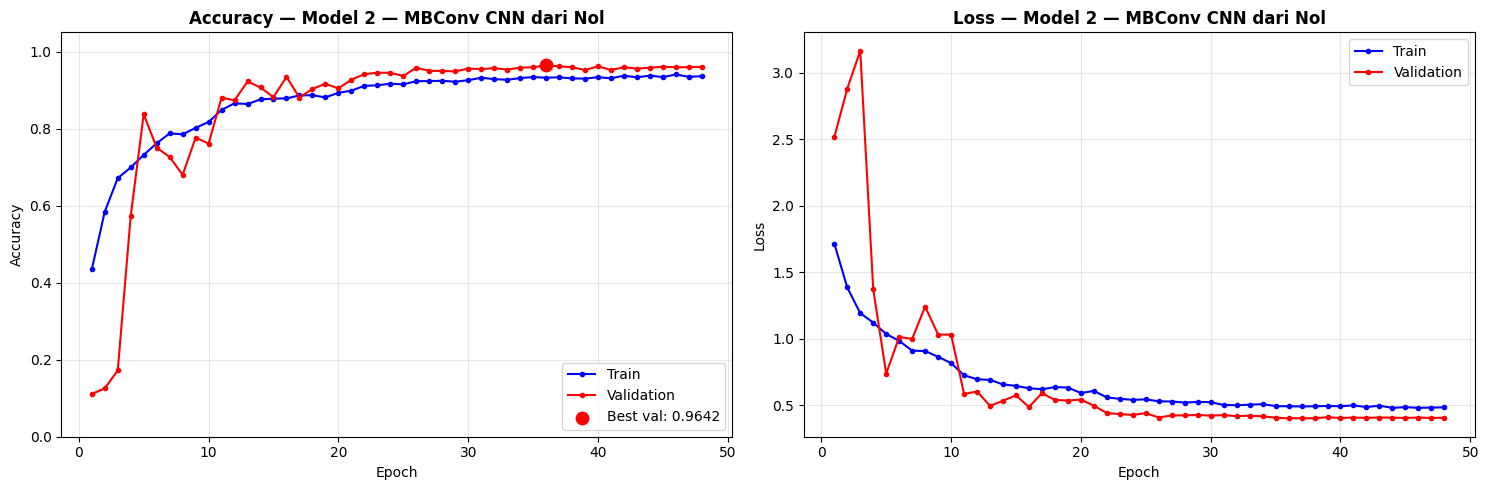


📊 Diagnosa Model 2 — MBConv CNN dari Nol:
   Train acc  : 0.9361  |  Val acc  : 0.9606  |  Gap : -0.0244
   ✅ GOOD FIT


In [28]:
plot_training_history(history2, 'Model 2 — MBConv CNN dari Nol')

## E.5 · Evaluasi Model 2 pada Validation Set

In [29]:
print(f"📂 Memuat model terbaik dari: {BEST_MODEL2_PATH}")
best_model2 = keras.models.load_model(BEST_MODEL2_PATH)

val_generator.reset()
val_loss2, val_acc2 = best_model2.evaluate(val_generator, verbose=1)
print(f"\nModel 2 — Val Loss     : {val_loss2:.4f}")
print(f"Model 2 — Val Accuracy : {val_acc2:.4f} ({val_acc2*100:.2f}%)")

📂 Memuat model terbaik dari: best_model2_mbconv.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9642 - loss: 0.4020

Model 2 — Val Loss     : 0.4020
Model 2 — Val Accuracy : 0.9642 (96.42%)


---
# 🅕 Perbandingan Model & Error Analysis

Evaluasi komprehensif dan analisis prediksi yang salah.

## F.1 · Kumpulkan Prediksi Kedua Model

In [30]:
# Prediksi Model 1
val_generator.reset()
y_proba1 = best_model1.predict(val_generator, verbose=1)
y_pred1  = np.argmax(y_proba1, axis=1)

# Prediksi Model 2
val_generator.reset()
y_proba2 = best_model2.predict(val_generator, verbose=1)
y_pred2  = np.argmax(y_proba2, axis=1)

y_true = val_generator.classes
print(f"Total sampel validasi: {len(y_true)}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step
Total sampel validasi: 837


## F.2 · Tabel Perbandingan Metrik

Membandingkan Accuracy, Precision, Recall, dan F1-Score kedua model secara berdampingan.

         PERBANDINGAN PERFORMA — VALIDATION SET
                           Accuracy  Precision    Recall  F1 (macro)  Val Loss
Model                                                                         
Model 1 — Conv2D 4-Blok    0.952210   0.941213  0.948228    0.943167    0.4308
Model 2 — MBConv dari Nol  0.964158   0.958778  0.960289    0.959204    0.4020


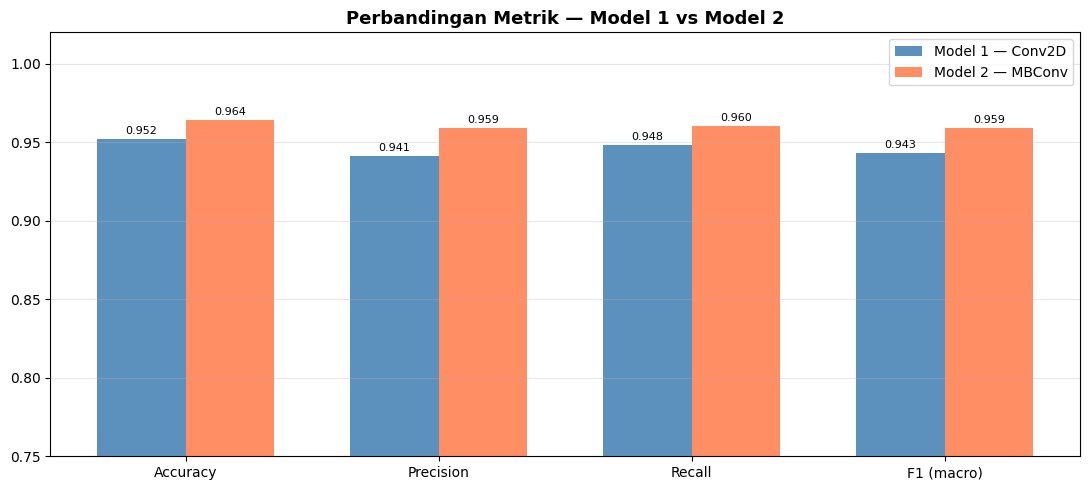


🏆 Model terbaik berdasarkan Accuracy: Model 2 (SeparableConv2D)


In [31]:
def get_metrics(y_true, y_pred, name, v_loss, v_acc):
    return {
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_true, y_pred),
        "Precision"  : precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall"     : recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1 (macro)" : f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Val Loss"   : round(v_loss, 4),
    }

row1 = get_metrics(y_true, y_pred1, "Model 1 — Conv2D 4-Blok",       val_loss1, val_acc1)
row2 = get_metrics(y_true, y_pred2, "Model 2 — MBConv dari Nol", val_loss2, val_acc2)

df_cmp = pd.DataFrame([row1, row2]).set_index("Model")
print("=" * 70)
print("         PERBANDINGAN PERFORMA — VALIDATION SET")
print("=" * 70)
print(df_cmp.to_string())
print("=" * 70)

# Bar chart
metrics_plot = ["Accuracy", "Precision", "Recall", "F1 (macro)"]
x = np.arange(len(metrics_plot)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, [row1[m] for m in metrics_plot], w,
            label="Model 1 — Conv2D",       color='steelblue', alpha=0.88)
b2 = ax.bar(x + w/2, [row2[m] for m in metrics_plot], w,
            label="Model 2 — MBConv", color='coral',  alpha=0.88)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_plot)
ax.set_ylim([0.75, 1.02])
ax.set_title("Perbandingan Metrik — Model 1 vs Model 2", fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

winner = "Model 1 (Conv2D)" if row1["Accuracy"] >= row2["Accuracy"] else "Model 2 (SeparableConv2D)"
print(f"\n🏆 Model terbaik berdasarkan Accuracy: {winner}")

## F.3 · Kurva Training Berdampingan

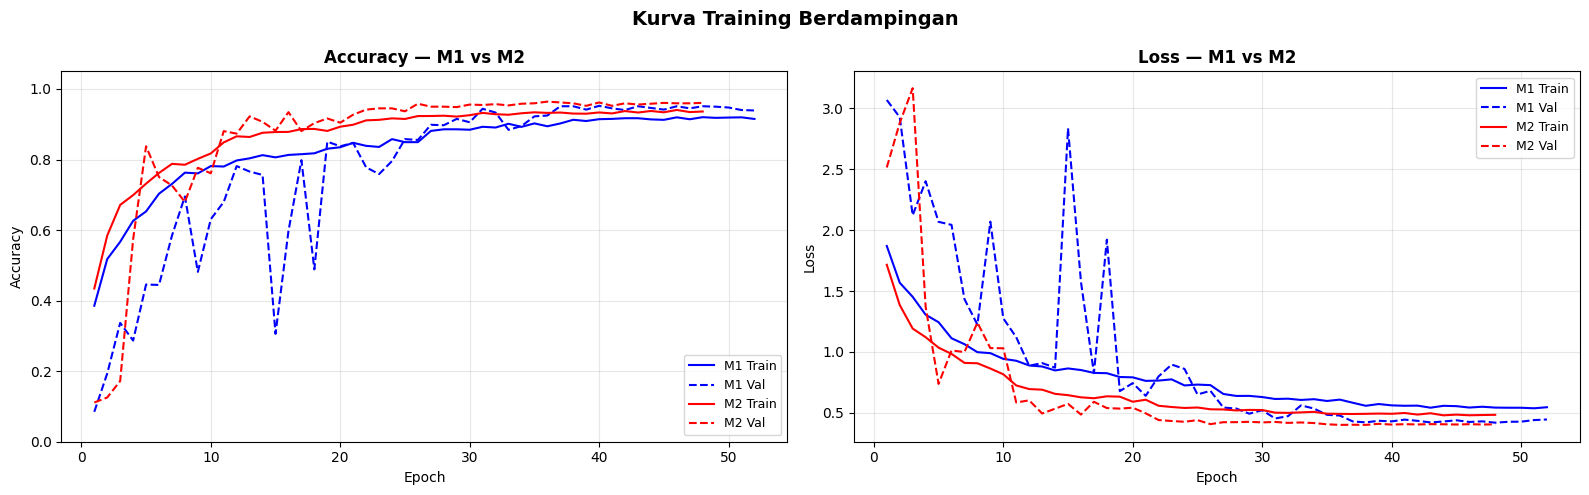

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ep1 = range(1, len(history1.history['val_accuracy']) + 1)
ep2 = range(1, len(history2.history['val_accuracy']) + 1)

axes[0].plot(ep1, history1.history['accuracy'],     'b-',  lw=1.5, label='M1 Train')
axes[0].plot(ep1, history1.history['val_accuracy'], 'b--', lw=1.5, label='M1 Val')
axes[0].plot(ep2, history2.history['accuracy'],     'r-',  lw=1.5, label='M2 Train')
axes[0].plot(ep2, history2.history['val_accuracy'], 'r--', lw=1.5, label='M2 Val')
axes[0].set_title("Accuracy — M1 vs M2", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0, 1.05]); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep1, history1.history['loss'],     'b-',  lw=1.5, label='M1 Train')
axes[1].plot(ep1, history1.history['val_loss'], 'b--', lw=1.5, label='M1 Val')
axes[1].plot(ep2, history2.history['loss'],     'r-',  lw=1.5, label='M2 Train')
axes[1].plot(ep2, history2.history['val_loss'], 'r--', lw=1.5, label='M2 Val')
axes[1].set_title("Loss — M1 vs M2", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle("Kurva Training Berdampingan", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## F.4 · Classification Report Kedua Model

In [33]:
print("=" * 58)
print("  Classification Report — MODEL 1 (Conv2D 4-Blok)")
print("=" * 58)
print(classification_report(y_true, y_pred1, target_names=CLASS_NAMES, zero_division=0))

print("=" * 58)
print("  Classification Report — MODEL 2 (MBConv dari Nol)")
print("=" * 58)
print(classification_report(y_true, y_pred2, target_names=CLASS_NAMES, zero_division=0))

  Classification Report — MODEL 1 (Conv2D 4-Blok)
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.96      0.96       114
              Forest       0.98      0.99      0.98        98
HerbaceousVegetation       0.90      0.85      0.87        65
             Highway       0.86      0.98      0.92        51
          Industrial       1.00      0.88      0.94        83
             Pasture       0.99      0.98      0.99       105
       PermanentCrop       0.79      0.94      0.86        48
         Residential       0.97      0.99      0.98        71
               River       0.98      0.94      0.96        93
             SeaLake       0.99      0.98      0.99       109

            accuracy                           0.95       837
           macro avg       0.94      0.95      0.94       837
        weighted avg       0.96      0.95      0.95       837

  Classification Report — MODEL 2 (MBConv dari Nol)
                      preci

## F.5 · Confusion Matrix Kedua Model

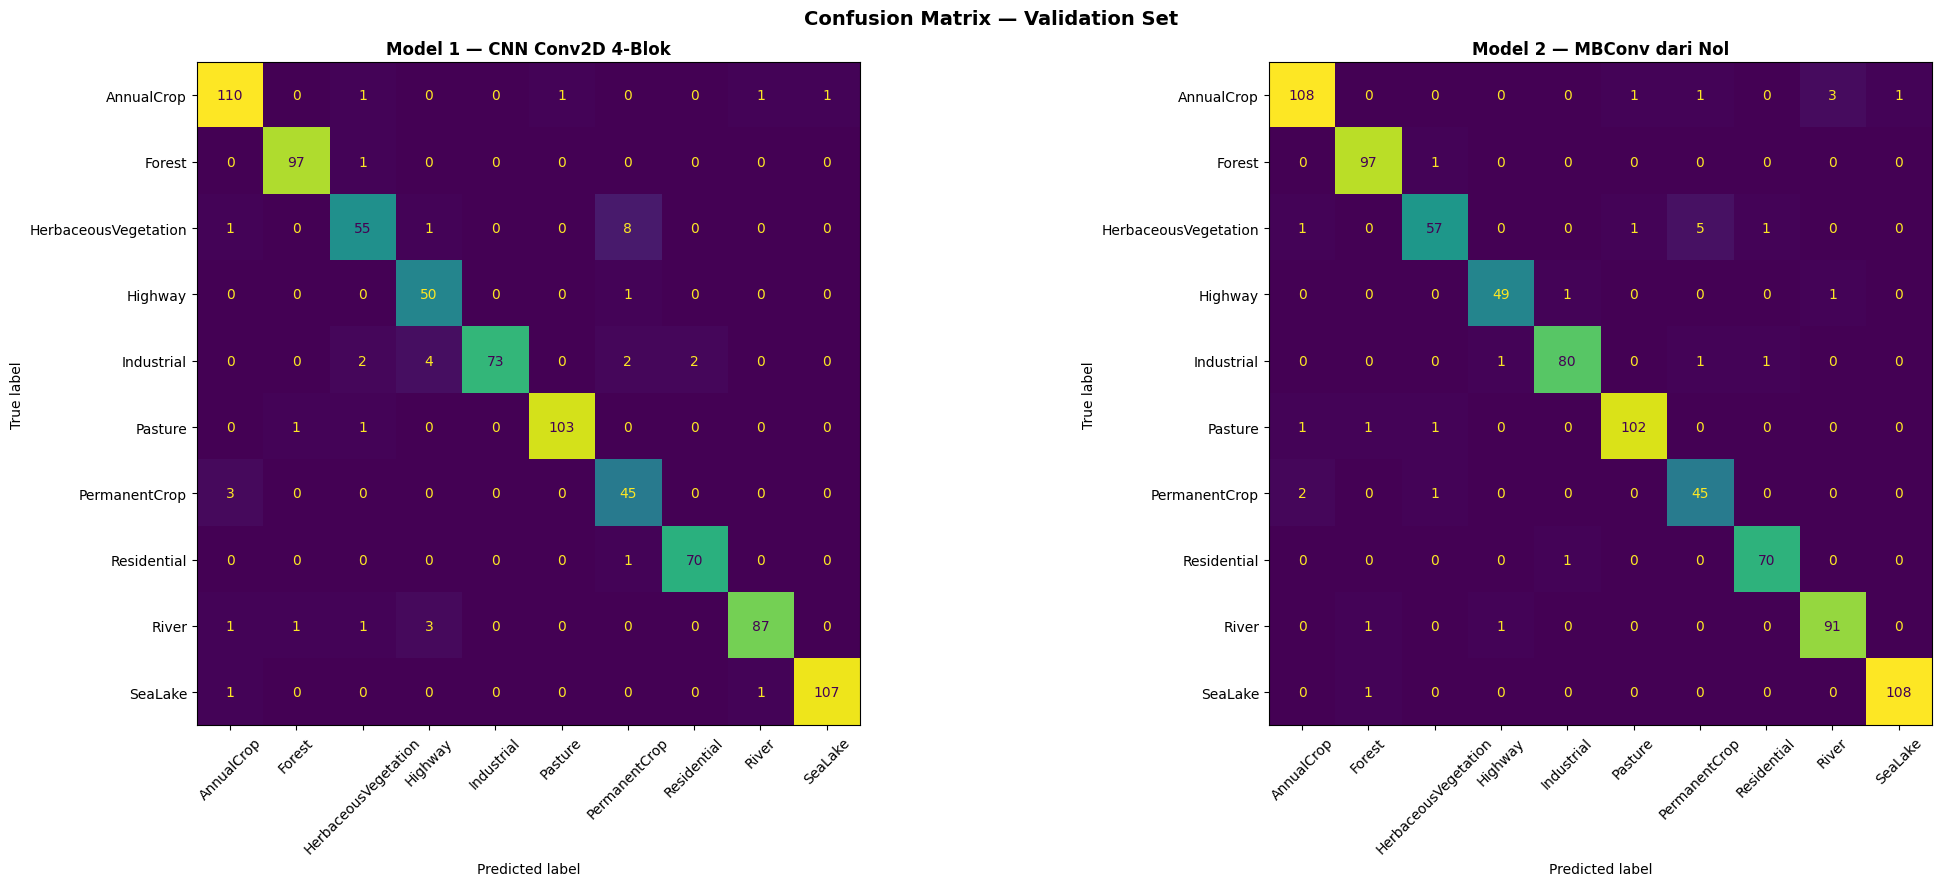

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, y_pred, title in [
    (axes[0], y_pred1, "Model 1 — CNN Conv2D 4-Blok"),
    (axes[1], y_pred2, "Model 2 — MBConv dari Nol"),
]:
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, xticks_rotation=45, values_format='d', colorbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle("Confusion Matrix — Validation Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## F.6 · Error Analysis — Analisis Prediksi yang Salah

Melihat gambar-gambar yang **salah diprediksi** oleh model terbaik untuk memahami pola kesalahan yang terjadi.

Error analysis menggunakan : Model 2 — MBConv dari Nol
Total prediksi salah       : 30 / 837
Error rate                 : 3.58%


/tmp/ipykernel_5846/3623263043.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5846/3623263043.py:35: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5846/3623263043.py:36: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_5846/3623263043.py:36: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.

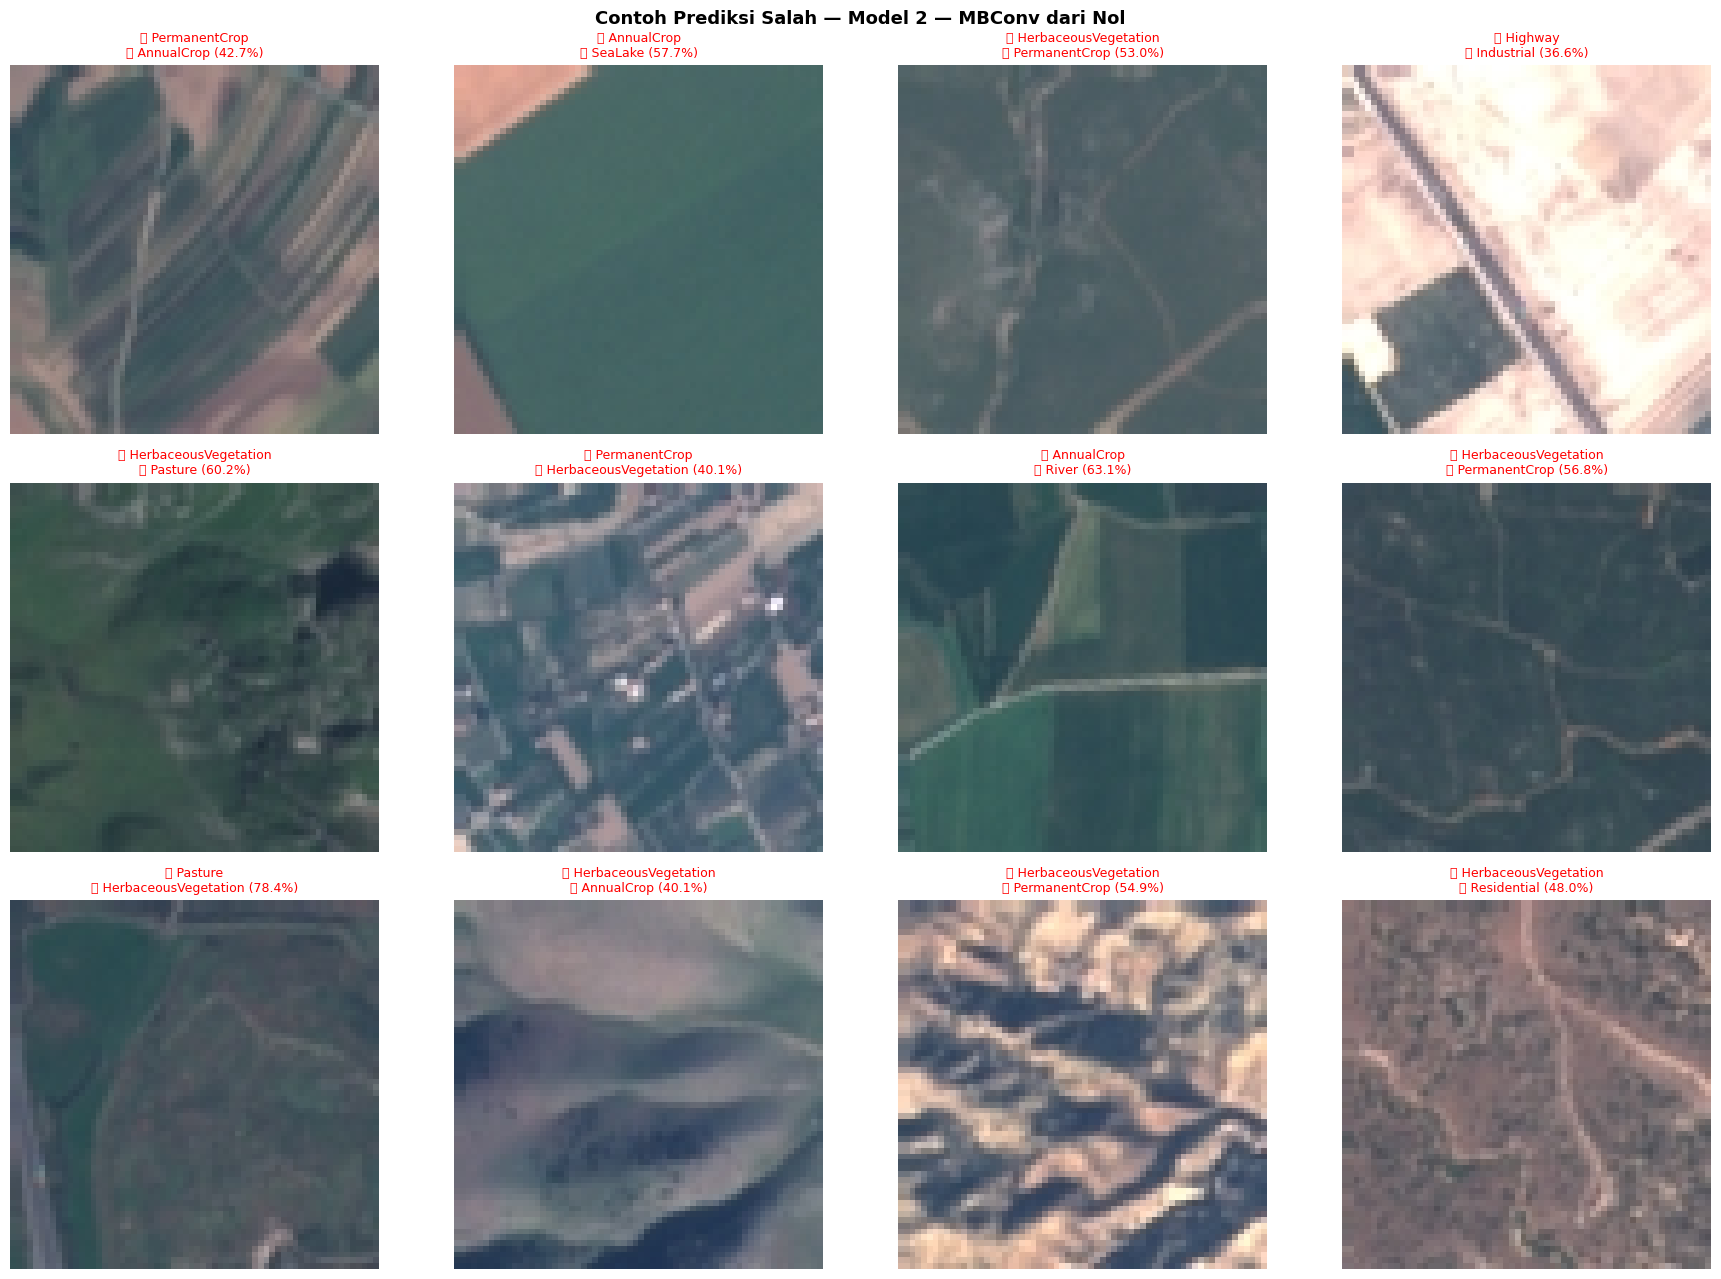

In [35]:
# Pilih model terbaik untuk error analysis
if val_acc1 >= val_acc2:
    ea_model, ea_pred, ea_proba = best_model1, y_pred1, y_proba1
    ea_name = "Model 1 — Conv2D 4-Blok"
else:
    ea_model, ea_pred, ea_proba = best_model2, y_pred2, y_proba2
    ea_name = "Model 2 — MBConv dari Nol"

wrong_idx = np.where(ea_pred != y_true)[0]
print(f"Error analysis menggunakan : {ea_name}")
print(f"Total prediksi salah       : {len(wrong_idx)} / {len(y_true)}")
print(f"Error rate                 : {len(wrong_idx)/len(y_true)*100:.2f}%")

# Tampilkan 12 contoh prediksi salah
val_generator.reset()
val_fps = [Path(p) for p in val_generator.filepaths]

n_show = min(12, len(wrong_idx))
sample_wrong = np.random.choice(wrong_idx, n_show, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()
for pi, idx in enumerate(sample_wrong):
    img = mpimg.imread(val_fps[idx])
    true_cls = CLASS_NAMES[y_true[idx]]
    pred_cls = CLASS_NAMES[ea_pred[idx]]
    conf     = ea_proba[idx][ea_pred[idx]] * 100
    axes[pi].imshow(img)
    axes[pi].set_title(
        f"✅ {true_cls}\n❌ {pred_cls} ({conf:.1f}%)",
        fontsize=9, color='red')
    axes[pi].axis('off')

plt.suptitle(f"Contoh Prediksi Salah — {ea_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## F.7 · Pola Kesalahan — Kelas yang Paling Sering Tertukar

In [36]:
from collections import Counter as Ctr

error_pairs = [(CLASS_NAMES[y_true[i]], CLASS_NAMES[ea_pred[i]]) for i in wrong_idx]
top_errors  = Ctr(error_pairs).most_common(15)

print(f"===== Top-15 Pasangan Kelas yang Sering Tertukar — {ea_name} =====")
print(f"{'Kelas Sebenarnya':<25} {'Diprediksi sebagai':<25} {'Jumlah':>7}")
print("-" * 60)
for (true_c, pred_c), cnt in top_errors:
    print(f"{true_c:<25} {pred_c:<25} {cnt:>7}")

print(f"\n===== Error Rate per Kelas =====")
print(f"{'Kelas':<25} {'Total':>7} {'Salah':>7} {'Error%':>9} {'Bar'}")
print("-" * 65)
for ci, cn in enumerate(CLASS_NAMES):
    mask  = y_true == ci
    total = mask.sum()
    wrong = (ea_pred[mask] != ci).sum()
    rate  = wrong / total if total > 0 else 0
    bar   = '█' * int(rate * 25)
    print(f"{cn:<25} {total:>7} {wrong:>7}  {rate*100:>6.1f}%  {bar}")

===== Top-15 Pasangan Kelas yang Sering Tertukar — Model 2 — MBConv dari Nol =====
Kelas Sebenarnya          Diprediksi sebagai         Jumlah
------------------------------------------------------------
HerbaceousVegetation      PermanentCrop                   5
AnnualCrop                River                           3
PermanentCrop             AnnualCrop                      2
AnnualCrop                Pasture                         1
AnnualCrop                SeaLake                         1
AnnualCrop                PermanentCrop                   1
Forest                    HerbaceousVegetation            1
HerbaceousVegetation      AnnualCrop                      1
HerbaceousVegetation      Residential                     1
HerbaceousVegetation      Pasture                         1
Highway                   River                           1
Highway                   Industrial                      1
Industrial                Residential                     1
Industrial      

---
# 🅖 Inferensi & Submission

Menggunakan model terbaik untuk prediksi test set dan membuat file submission.

## G.1 · Pilih Model Terbaik & Prediksi Test Set

Model yang digunakan dipilih otomatis berdasarkan **val_accuracy tertinggi**.

In [37]:
# ===== INFERENSI DENGAN TTA BATCH =====

# Pilih model terbaik
if val_acc1 >= val_acc2:
    final_model = best_model1
    final_name  = "Model 1 — Conv2D 4-Blok"
else:
    final_model = best_model2
    final_name  = "Model 2 — MBConv dari Nol"

print(f"🏆 Model terpilih: {final_name}")
print(f"   Val Acc M1: {val_acc1:.4f}  |  Val Acc M2: {val_acc2:.4f}")

# Baca sample_submission
sample_sub      = pd.read_csv(SUBMISSION_SAMPLE)
test_image_ids  = sample_sub["image_id"].tolist()
test_images     = [TEST_DIR / img_id for img_id in test_image_ids]

missing = [p.name for p in test_images if not p.exists()]
if missing:
    raise FileNotFoundError(f"{len(missing)} file tidak ditemukan: {missing[:5]}")

print(f"✅ {len(test_images)} file test siap diprediksi.")

def preprocess_image(img_path, target_size):
    img = load_img(img_path, target_size=target_size)
    return img_to_array(img).astype("float32") / 255.0

def make_tta_batch(img_arr):
    versions = [
        img_arr,
        np.fliplr(img_arr),
        np.flipud(img_arr),
        np.fliplr(np.flipud(img_arr)),
        np.rot90(img_arr, k=1),
        np.rot90(img_arr, k=2),
        np.rot90(img_arr, k=3),
        np.fliplr(np.rot90(img_arr, k=1)),
    ]
    return np.array(versions)

print("\n🔍 Membuat batch TTA...")

tta_batches = []
for img_path in test_images:
    arr = preprocess_image(img_path, IMG_SIZE)
    tta_batches.append(make_tta_batch(arr))

# Bentuk awal: (jumlah_gambar, 8, H, W, 3)
tta_batches = np.array(tta_batches)

num_images = tta_batches.shape[0]
num_tta    = tta_batches.shape[1]

# Ubah jadi: (jumlah_gambar * 8, H, W, 3)
tta_input = tta_batches.reshape(-1, *tta_batches.shape[2:])

print(f"✅ Shape TTA input: {tta_input.shape}")

print("\n🔍 Prediksi test set dengan TTA batch...")
tta_pred = final_model.predict(
    tta_input,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Balikkan jadi: (jumlah_gambar, 8, num_classes)
tta_pred = tta_pred.reshape(num_images, num_tta, -1)

# Rata-rata prediksi dari 8 augmentasi
mean_pred = tta_pred.mean(axis=1)

pred_indices = np.argmax(mean_pred, axis=1)
pred_labels  = [IDX_TO_CLASS[i] for i in pred_indices]

submission = pd.DataFrame({
    "image_id": test_image_ids,
    "label": pred_labels
})

submission.to_csv("submission_tta.csv", index=False)

print("\n✅ Prediksi TTA selesai.")
print(submission.head())

🏆 Model terpilih: Model 2 — MBConv dari Nol
   Val Acc M1: 0.9522  |  Val Acc M2: 0.9642
✅ 1200 file test siap diprediksi.

🔍 Membuat batch TTA...
✅ Shape TTA input: (9600, 128, 128, 3)

🔍 Prediksi test set dengan TTA batch...
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step

✅ Prediksi TTA selesai.
               image_id                 label
0  img_9c8e90b0c9ab.jpg               Pasture
1  img_8270bdcdfd01.jpg  HerbaceousVegetation
2  img_99d65acb7b87.jpg  HerbaceousVegetation
3  img_903ef169aa6c.jpg               SeaLake
4  img_edaf6f95c449.jpg         PermanentCrop


## G.2 · Buat & Simpan `submission.csv`

In [39]:
# ===== BUAT SUBMISSION.CSV =====

# Menggunakan hasil dari cell G.1
submission_df = submission.copy()

# Safety: pastikan urutan sama persis dengan sample_submission
if list(submission_df['image_id']) != list(sample_sub['image_id']):
    print("⚠️ Urutan berbeda, melakukan merge ulang...")
    submission_df = sample_sub[['image_id']].merge(
        submission_df, on='image_id', how='left'
    )
else:
    print("✅ Urutan image_id sudah sesuai sample_submission.")

null_count = submission_df['label'].isna().sum()
if null_count > 0:
    print(f"⚠️ {null_count} gambar tidak memiliki prediksi!")
else:
    print("✅ Semua gambar memiliki prediksi.")

SUBMISSION_PATH = 'submission.csv'
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f"\n📄 submission.csv disimpan → {SUBMISSION_PATH}")
print(f"   Jumlah baris : {len(submission_df)}")
print("\nPreview 10 baris pertama:")
print(submission_df.head(10).to_string(index=False))
print("\nDistribusi prediksi:")
print(submission_df['label'].value_counts())


✅ Urutan image_id sudah sesuai sample_submission.
✅ Semua gambar memiliki prediksi.

📄 submission.csv disimpan → submission.csv
   Jumlah baris : 1200

Preview 10 baris pertama:
            image_id                label
img_9c8e90b0c9ab.jpg              Pasture
img_8270bdcdfd01.jpg HerbaceousVegetation
img_99d65acb7b87.jpg HerbaceousVegetation
img_903ef169aa6c.jpg              SeaLake
img_edaf6f95c449.jpg        PermanentCrop
img_d30e3f17cf1f.jpg HerbaceousVegetation
img_7c5c54a0ec6a.jpg           AnnualCrop
img_50f060346f33.jpg               Forest
img_f123e7573a93.jpg              SeaLake
img_63662ee5c0e5.jpg              SeaLake

Distribusi prediksi:
label
HerbaceousVegetation    132
Residential             125
Forest                  123
Highway                 122
SeaLake                 121
Pasture                 119
AnnualCrop              119
River                   116
Industrial              115
PermanentCrop           108
Name: count, dtype: int64


## G.3 · Visualisasi Sampel Prediksi Test

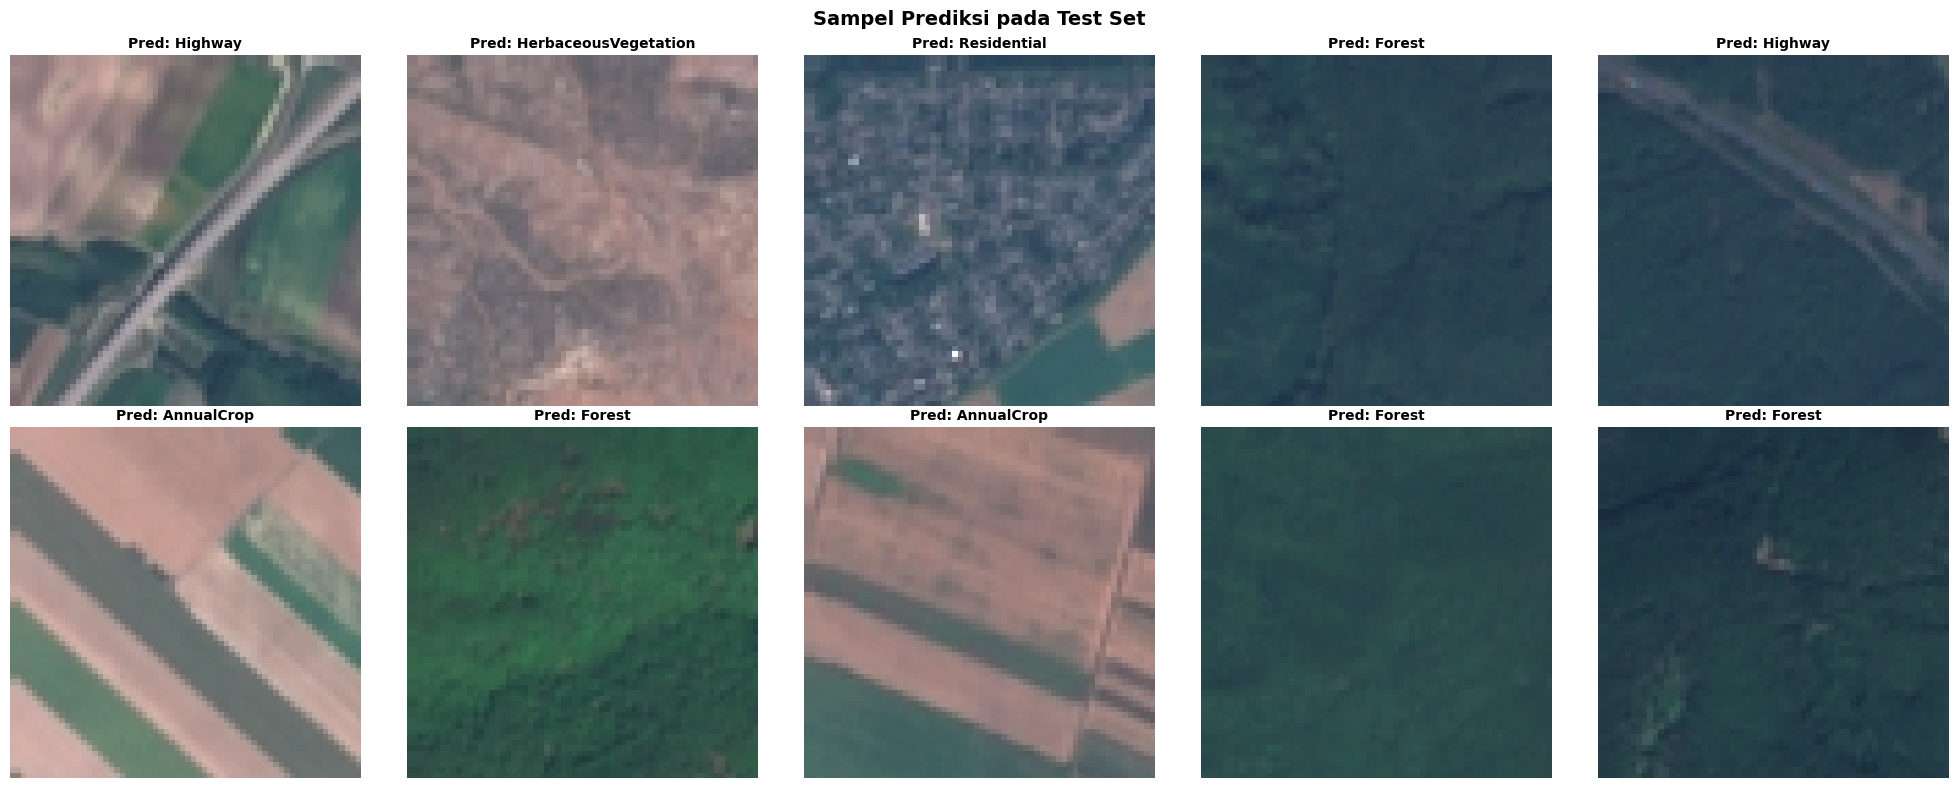

In [40]:
# ===== TAMPILKAN SAMPEL PREDIKSI TEST =====

sample_indices = random.sample(range(len(test_images)), min(10, len(test_images)))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for plot_idx, img_idx in enumerate(sample_indices):
    img_path = test_images[img_idx]
    img = mpimg.imread(img_path)
    pred_label = submission_df.loc[
        submission_df['image_id'] == img_path.name, 'label'
    ].values
    pred_text = pred_label[0] if len(pred_label) > 0 else "?"

    axes[plot_idx].imshow(img)
    axes[plot_idx].set_title(f"Pred: {pred_text}", fontsize=10, fontweight='bold')
    axes[plot_idx].set_xlabel(img_path.name[:20], fontsize=7)
    axes[plot_idx].axis('off')

plt.suptitle("Sampel Prediksi pada Test Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()